Install & Import

In [16]:
!pip install xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, string, pickle, warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from scipy.sparse import hstack

print("Done")

Done


Upload & Load Dataset

In [17]:
df = pd.read_csv('fake_job_postings.csv')
print(df.shape)
df.head()

(17880, 18)


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


EDA


fraudulent
0    17014
1      866
Name: count, dtype: int64
Fraud %: 4.84%


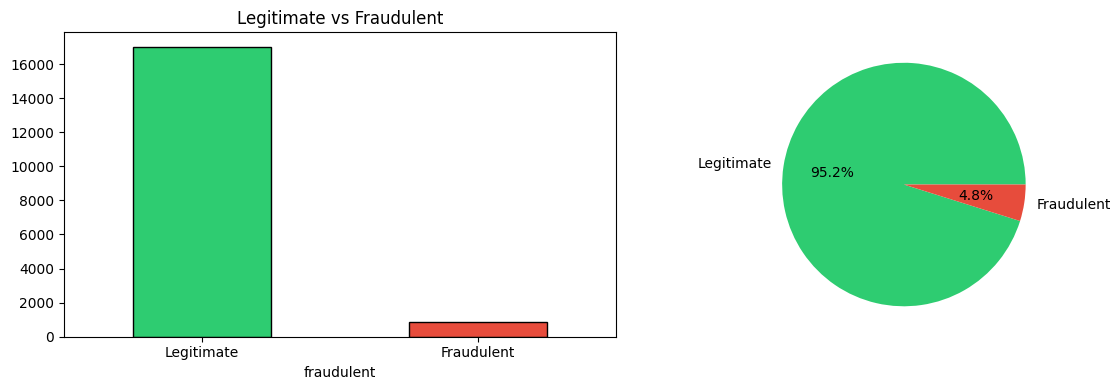

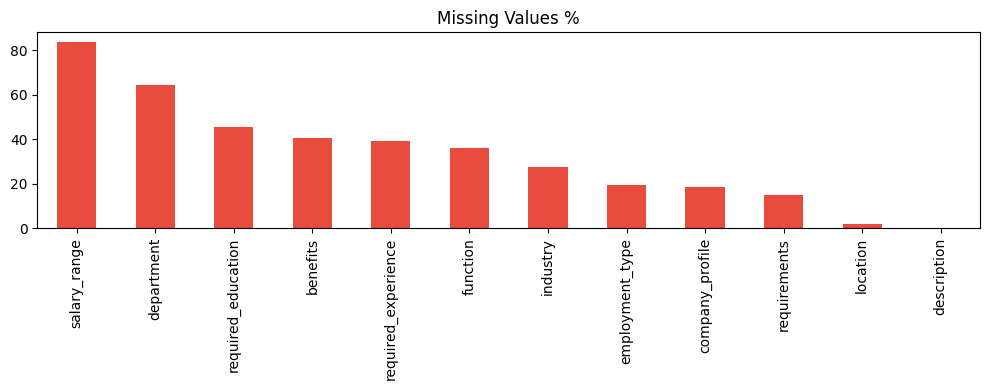

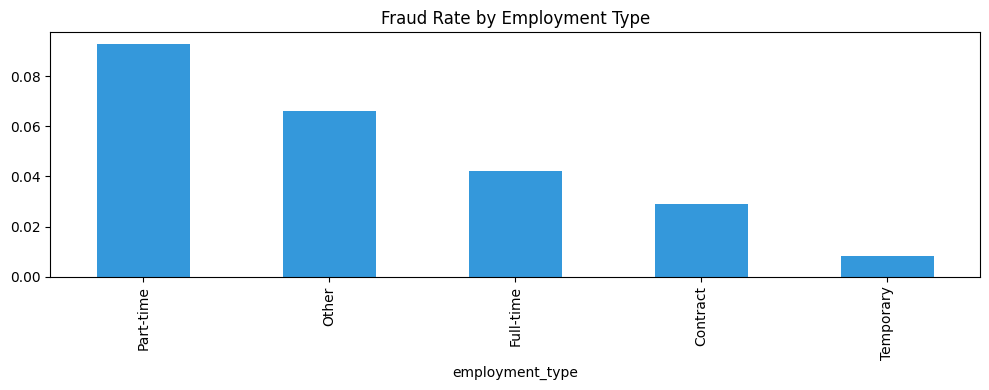

In [18]:
print(df['fraudulent'].value_counts())
print(f"Fraud %: {df['fraudulent'].mean()*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['fraudulent'].value_counts().plot(kind='bar', ax=axes[0],
    color=['#2ecc71','#e74c3c'], edgecolor='black')
axes[0].set_title('Legitimate vs Fraudulent')
axes[0].set_xticklabels(['Legitimate', 'Fraudulent'], rotation=0)

df['fraudulent'].value_counts().plot(kind='pie', ax=axes[1],
    autopct='%1.1f%%', colors=['#2ecc71','#e74c3c'],
    labels=['Legitimate','Fraudulent'])
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing[missing > 0].plot(kind='bar', color='#e74c3c', figsize=(10,4))
plt.title('Missing Values %')
plt.tight_layout()
plt.show()

df.groupby('employment_type')['fraudulent'].mean().sort_values(ascending=False).plot(
    kind='bar', color='#3498db', figsize=(10,4))
plt.title('Fraud Rate by Employment Type')
plt.tight_layout()
plt.show()

Cleaning & Preprocessing


In [19]:
text_cols = ['title','company_profile','description',
             'requirements','benefits','employment_type',
             'required_experience','required_education','industry','function']
for col in text_cols:
    df[col] = df[col].fillna('')

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['combined_text'] = (df['title'] + ' ' + df['company_profile'] + ' ' +
                       df['description'] + ' ' + df['requirements'] + ' ' + df['benefits'])
df['combined_text'] = df['combined_text'].apply(clean_text)

le = LabelEncoder()
cat_cols = ['employment_type','required_experience','required_education','industry','function']
for col in cat_cols:
    df[col+'_enc'] = le.fit_transform(df[col].astype(str))

print("Preprocessing done")

Preprocessing done


Feature Engineering (TF-IDF)

In [20]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2),
                        stop_words='english', min_df=2)
X_text = tfidf.fit_transform(df['combined_text'])

struct_cols = [col+'_enc' for col in cat_cols] + ['telecommuting','has_company_logo','has_questions']
X_struct = df[struct_cols].values

X = hstack([X_text, X_struct])
y = df['fraudulent']

print("X shape:", X.shape)
print("y distribution:\n", y.value_counts())

X shape: (17880, 5008)
y distribution:
 fraudulent
0    17014
1      866
Name: count, dtype: int64


Train/Test Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)

Train size: (14304, 5008)
Test size : (3576, 5008)


Train Multiple Models

In [22]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'XGBoost'            : XGBClassifier(scale_pos_weight=10, use_label_encoder=False,
                                          eval_metric='logloss', random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    results[name] = {'Accuracy': round(acc*100,2), 'ROC-AUC': round(auc,4)}
    print(f"\n{'='*40}")
    print(f"🔹 {name}")
    print(f"Accuracy : {acc*100:.2f}%")
    print(f"ROC-AUC  : {auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Legitimate','Fraudulent']))


🔹 Logistic Regression
Accuracy : 95.89%
ROC-AUC  : 0.9876
              precision    recall  f1-score   support

  Legitimate       0.99      0.96      0.98      3403
  Fraudulent       0.55      0.90      0.68       173

    accuracy                           0.96      3576
   macro avg       0.77      0.93      0.83      3576
weighted avg       0.97      0.96      0.96      3576


🔹 Random Forest
Accuracy : 97.87%
ROC-AUC  : 0.9894
              precision    recall  f1-score   support

  Legitimate       0.98      1.00      0.99      3403
  Fraudulent       0.98      0.57      0.72       173

    accuracy                           0.98      3576
   macro avg       0.98      0.79      0.86      3576
weighted avg       0.98      0.98      0.98      3576


🔹 XGBoost
Accuracy : 98.63%
ROC-AUC  : 0.9891
              precision    recall  f1-score   support

  Legitimate       0.99      1.00      0.99      3403
  Fraudulent       0.90      0.80      0.85       173

    accuracy           

Evaluation & Visualizations

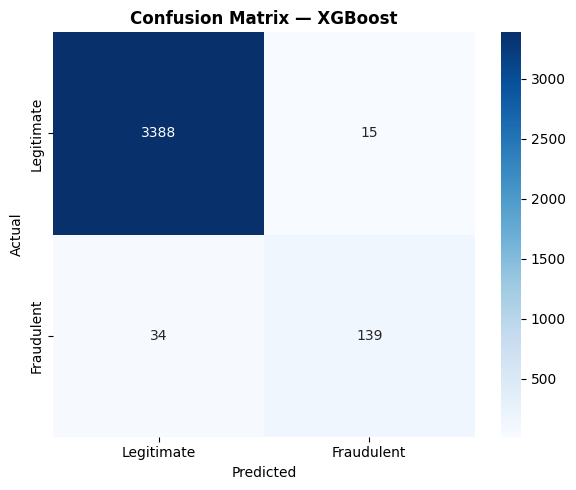

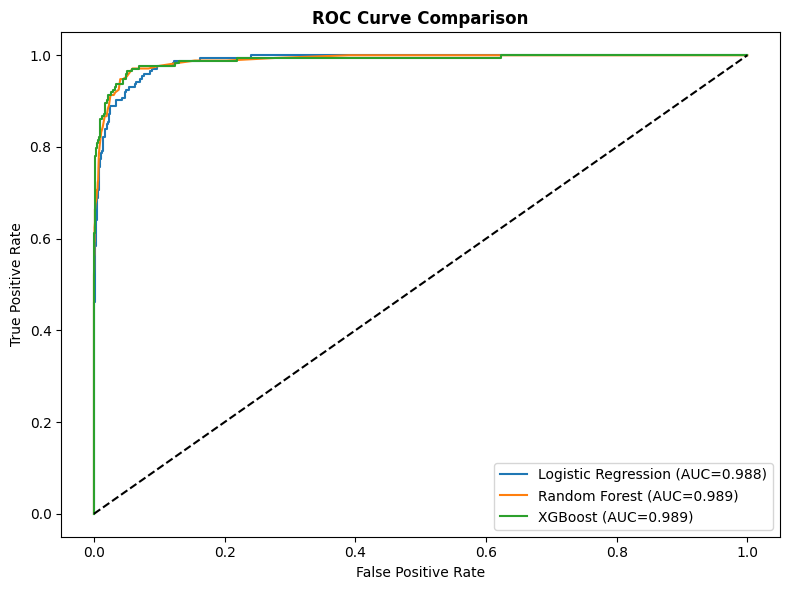

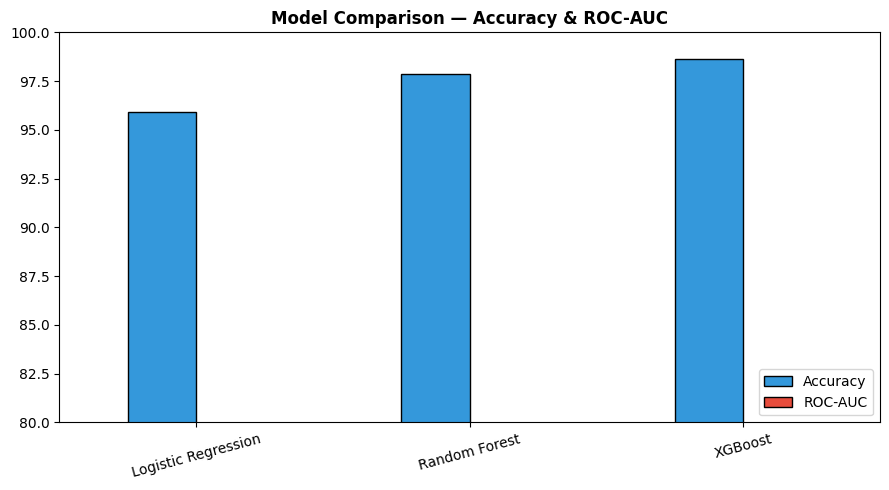

In [23]:
best_model = models['XGBoost']
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate','Fraudulent'],
            yticklabels=['Legitimate','Fraudulent'])
plt.title('Confusion Matrix — XGBoost', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
for name, model in models.items():
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:,1])
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

results_df = pd.DataFrame(results).T
results_df.plot(kind='bar', figsize=(9,5), color=['#3498db','#e74c3c'], edgecolor='black')
plt.title('Model Comparison — Accuracy & ROC-AUC', fontweight='bold')
plt.xticks(rotation=15)
plt.ylim(80, 100)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Save Best Model

In [24]:
pickle.dump(best_model, open('fake_job_model.pkl', 'wb'))
pickle.dump(tfidf, open('tfidf_vectorizer.pkl', 'wb'))

files.download('fake_job_model.pkl')
files.download('tfidf_vectorizer.pkl')

print("Model saved and downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model saved and downloaded!


Test on New Input

In [25]:
def predict_job(title, description, requirements):
    text = clean_text(title + ' ' + description + ' ' + requirements)
    text_vec = tfidf.transform([text])


    struct = np.zeros((1, len(struct_cols)))
    combined = hstack([text_vec, struct])

    pred = best_model.predict(combined)[0]
    prob = best_model.predict_proba(combined)[0][1]

    label = "🚨 FRAUDULENT" if pred == 1 else "✅ LEGITIMATE"
    print(f"Prediction : {label}")
    print(f"Fraud Probability: {prob*100:.2f}%")


predict_job(
    title="Work from home data entry job - earn $5000/week!",
    description="No experience needed. Just send $50 registration fee to get started.",
    requirements="None"
)

Prediction : 🚨 FRAUDULENT
Fraud Probability: 98.93%
